In [1]:
ls

 Volume in drive C has no label.
 Volume Serial Number is 7067-B87D

 Directory of c:\Users\dell\Downloads

13-06-2026  18:26    <DIR>          .
13-06-2026  15:33    <DIR>          ..
30-03-2026  07:12            41,980 2026327924 (1).jpeg
30-03-2026  07:11            41,980 2026327924.jpeg
30-03-2026  07:06            95,339 2026327924.pdf
02-01-2026  07:51         1,040,571 31DEC2025.pdf
09-04-2026  17:24           177,986 agc.pdf
30-03-2026  06:46           161,769 akashpass.pdf
30-03-2026  06:48           160,741 akashpic.jpeg
30-03-2026  06:50           106,022 akashsign.jpeg
30-03-2026  06:58           107,049 akashsignpdf.pdf
15-05-2026  13:12         1,911,333 amazon-book-reviews.ipynb
04-12-2025  15:58        14,362,592 apache-tomcat-10.1.26.exe
30-03-2026  07:01           305,439 apic.jpeg
26-02-2026  07:57            49,616 Application_form_615403.pdf
30-03-2026  06:54           221,202 Application_form_SRM.pdf
23-02-2026  09:09           241,874 APS certificate.pdf
28-05-2

In [2]:
# CELL 1: INSTALLATIONS AND IMPORTS
!pip install codecarbon yfinance -q


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
#Environment Setup

In [4]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Dropout, UpSampling2D, GlobalAveragePooling2D
from tensorflow.keras.applications import InceptionV3
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from codecarbon import EmissionsTracker

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

ModuleNotFoundError: No module named 'tensorflow'

In [5]:
#Experiment 1 - Tabular Data (Feedforward Neural Network)

In [6]:
# CELL 2: TABULAR DATA & FEEDFORWARD NETWORK
print("--- STARTING EXPERIMENT 1: TABULAR FNN ---")

# 1. Generate large tabular dataset (100,000 rows, 20 features)
X_tab, y_tab = make_classification(n_samples=100000, n_features=20, n_classes=2, random_state=42)
X_train_tab, X_test_tab, y_train_tab, y_test_tab = train_test_split(X_tab, y_tab, test_size=0.2)

# 2. Build Feedforward Neural Network
model_fnn = Sequential([
    Dense(128, activation='relu', input_shape=(20,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
model_fnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Track Emissions
tracker = EmissionsTracker(project_name="Tabular_FNN", measure_power_secs=1)
tracker.start()

print("Training FNN...")
history_fnn = model_fnn.fit(X_train_tab, y_train_tab, epochs=5, batch_size=64, validation_split=0.2, verbose=1)

# 4. Stop Tracking
emissions_fnn = tracker.stop()
loss, acc_fnn = model_fnn.evaluate(X_test_tab, y_test_tab, verbose=0)
print(f"FNN Accuracy: {acc_fnn:.4f} | CO2 Emitted: {emissions_fnn:.6f} kg")

--- STARTING EXPERIMENT 1: TABULAR FNN ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[codecarbon WARNING @ 15:32:40] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 15:32:40] [setup] RAM Tracking...
[codecarbon INFO @ 15:32:40] [setup] CPU Tracking...
[codecarbon WARNING @ 15:32:42] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 15:32:42] We will use the default power consumption of 4 W per thread for your 2 CPU, so 8W.
[codecarbon WARNING @ 15:32:42] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subs

Training FNN...
Epoch 1/5


[codecarbon INFO @ 15:32:44] Energy consumed for RAM : 0.000006 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 15:32:45] Delta energy consumed for CPU with cpu_load : 0.000001 kWh, power : 1.4259558103999999 W
[codecarbon INFO @ 15:32:45] Energy consumed for All CPU : 0.000001 kWh
[codecarbon INFO @ 15:32:45] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 15:32:45] Energy consumed for all GPUs : 0.000011 kWh. Total GPU Power : 16.4226585852996 W
[codecarbon INFO @ 15:32:45] 0.000018 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 15:32:45] Energy consumed for RAM : 0.000007 kWh. RAM Power : 10.0 W


  21/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6257 - loss: 0.6382  

...

 980/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8758 - loss: 0.2913

[codecarbon INFO @ 15:33:03] Energy consumed for RAM : 0.000031 kWh. RAM Power : 10.0 W


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8746 - loss: 0.2944 - val_accuracy: 0.8682 - val_loss: 0.2996


[codecarbon INFO @ 15:33:03] Energy consumed for RAM : 0.000033 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 15:33:04] Delta energy consumed for CPU with cpu_load : 0.000000 kWh, power : 2.4335451116 W
[codecarbon INFO @ 15:33:04] Energy consumed for All CPU : 0.000013 kWh
[codecarbon INFO @ 15:33:04] Energy consumed for all GPUs : 0.000162 kWh. Total GPU Power : 27.980115068288757 W
[codecarbon INFO @ 15:33:04] 0.000208 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 15:33:04] Delta energy consumed for CPU with cpu_load : 0.000000 kWh, power : 0.9684343232000001 W
[codecarbon INFO @ 15:33:04] Energy consumed for All CPU : 0.000013 kWh
[codecarbon INFO @ 15:33:04] Energy consumed for all GPUs : 0.000163 kWh. Total GPU Power : 15.168719130498816 W
[codecarbon INFO @ 15:33:04] 0.000209 kWh of electricity and 0.000000 L of water were used since the beginning.


FNN Accuracy: 0.8705 | CO2 Emitted: 0.000098 kg


In [7]:
#Experiment 2 - Computer Vision (CIFAR-10 + InceptionV3)

In [8]:
# CELL 3: COMPUTER VISION & DEEP CNN (INCEPTION)
print("\n--- STARTING EXPERIMENT 2: VISION INCEPTION ---")

# 1. Load CIFAR-10
(X_train_cv, y_train_cv), (X_test_cv, y_test_cv) = tf.keras.datasets.cifar10.load_data()
X_train_cv, X_test_cv = X_train_cv / 255.0, X_test_cv / 255.0

# 2. Build Model (Upsample 32x32 -> 96x96, then InceptionV3)
base_model = InceptionV3(weights=None, include_top=False, input_shape=(96, 96, 3))
model_cnn = Sequential([
    UpSampling2D(size=(3,3), input_shape=(32, 32, 3)), # Scales to 96x96
    base_model,
    GlobalAveragePooling2D(),
    Dense(10, activation='softmax')
])
model_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 3. Track Emissions
tracker = EmissionsTracker(project_name="Vision_Inception", measure_power_secs=1)
tracker.start()

print("Training Inception CNN (This will take the most energy)...")
# Using only 3 epochs so the live demo doesn't take an hour
history_cnn = model_cnn.fit(X_train_cv, y_train_cv, epochs=3, batch_size=128, validation_split=0.2, verbose=1)

emissions_cnn = tracker.stop()
loss, acc_cnn = model_cnn.evaluate(X_test_cv, y_test_cv, verbose=0)
print(f"CNN Accuracy: {acc_cnn:.4f} | CO2 Emitted: {emissions_cnn:.6f} kg")


--- STARTING EXPERIMENT 2: VISION INCEPTION ---
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/up_sampling2d.py:72: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
[codecarbon WARNING @ 15:33:25] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 15:33:25] [setup] RAM Tracking...
[codecarbon INFO @ 15:33:25] [setup] CPU Tracking...
[codecarbon WARNING @ 15:33:25] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 15:33:25] We will use the default power consumption of 4 W per thread for your 2 CPU, so 8W.
[codecarbon WARNING @ 15:33:25] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarb

Training Inception CNN (This will take the most energy)...


[codecarbon INFO @ 15:33:27] Energy consumed for RAM : 0.000006 kWh. RAM Power : 10.0 W


Epoch 1/3


...

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.5706 - loss: 1.2616

[codecarbon INFO @ 15:37:46] Delta energy consumed for CPU with cpu_load : 0.000000 kWh, power : 0.9831264848 W
[codecarbon INFO @ 15:37:46] Energy consumed for All CPU : 0.000081 kWh
[codecarbon INFO @ 15:37:46] Energy consumed for all GPUs : 0.003623 kWh. Total GPU Power : 59.432910272234416 W
[codecarbon INFO @ 15:37:46] 0.004054 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 15:37:47] Energy consumed for RAM : 0.000352 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 15:37:47] Delta energy consumed for CPU with cpu_load : 0.000000 kWh, power : 0.8660968352 W
[codecarbon INFO @ 15:37:47] Energy consumed for All CPU : 0.000081 kWh
[codecarbon INFO @ 15:37:47] Energy consumed for all GPUs : 0.003641 kWh. Total GPU Power : 66.77322742450617 W
[codecarbon INFO @ 15:37:47] 0.004074 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 15:37:48] Energy consumed for RAM : 0.000353 kWh. RAM Power : 10.0 W
[codeca

313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 145ms/step - accuracy: 0.5881 - loss: 1.1985 - val_accuracy: 0.5579 - val_loss: 1.2764


[codecarbon INFO @ 15:37:49] Energy consumed for RAM : 0.000356 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 15:37:49] Delta energy consumed for CPU with cpu_load : 0.000000 kWh, power : 0.8068366592 W
[codecarbon INFO @ 15:37:49] Energy consumed for All CPU : 0.000081 kWh
[codecarbon INFO @ 15:37:49] Energy consumed for all GPUs : 0.003675 kWh. Total GPU Power : 55.538137921126676 W
[codecarbon INFO @ 15:37:49] 0.004112 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon WARNING @ 15:37:49] No power samples collected, returning 0 W
[codecarbon INFO @ 15:37:49] Delta energy consumed for CPU with cpu_load : 0.000000 kWh, power : 0.0 W
[codecarbon INFO @ 15:37:49] Energy consumed for All CPU : 0.000081 kWh
[codecarbon INFO @ 15:37:49] Energy consumed for all GPUs : 0.003676 kWh. Total GPU Power : 133.5495095555775 W
[codecarbon INFO @ 15:37:49] 0.004114 kWh of electricity and 0.000000 L of water were used since the beginning.


CNN Accuracy: 0.5611 | CO2 Emitted: 0.001937 kg


In [9]:
#Experiment 3 - Time Series (Bitcoin + Deep BiLSTM)

In [10]:
# CELL 4: TIME SERIES & DEEP BILSTM
print("\n--- STARTING EXPERIMENT 3: BTC TIME SERIES BILSTM ---")

# 1. Fetch 10 years of BTC Data
btc_data = yf.download('BTC-USD', period='10y')
closes = btc_data['Close'].values.reshape(-1, 1)

# 2. Preprocess (Scale and create 60-day windows)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(closes)

X_ts, y_ts = [], []
for i in range(60, len(scaled_data)):
    X_ts.append(scaled_data[i-60:i, 0])
    y_ts.append(scaled_data[i, 0])
X_ts, y_ts = np.array(X_ts), np.array(y_ts)
X_ts = np.reshape(X_ts, (X_ts.shape[0], X_ts.shape[1], 1))

X_train_ts, X_test_ts, y_train_ts, y_test_ts = train_test_split(X_ts, y_ts, test_size=0.2, shuffle=False)

# 3. Build Deep BiLSTM
model_lstm = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(X_ts.shape[1], 1)),
    Dropout(0.2),
    Bidirectional(LSTM(64)),
    Dropout(0.2),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# 4. Track Emissions
tracker = EmissionsTracker(project_name="TimeSeries_BiLSTM", measure_power_secs=1)
tracker.start()

print("Training Deep BiLSTM...")
history_lstm = model_lstm.fit(X_train_ts, y_train_ts, epochs=5, batch_size=32, validation_split=0.1, verbose=1)

emissions_lstm = tracker.stop()
# For regression, we evaluate on Loss (MSE) rather than accuracy
loss_lstm = model_lstm.evaluate(X_test_ts, y_test_ts, verbose=0)
print(f"BiLSTM Test Loss (MSE): {loss_lstm:.6f} | CO2 Emitted: {emissions_lstm:.6f} kg")


--- STARTING EXPERIMENT 3: BTC TIME SERIES BILSTM ---


/tmp/ipykernel_1005/3741907485.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc_data = yf.download('BTC-USD', period='10y')
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
[codecarbon WARNING @ 15:38:01] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 15:38:01] [setup] RAM Tracking...
[codecarbon INFO @ 15:38:01] [setup] CPU Tracking...
[codecarbon WARNING @ 15:38:01] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 15:38:01] We will use the default power consumption of 4 W per thread for your 2 CPU, so 8W.
[codecarbon WARNING 

Training Deep BiLSTM...
Epoch 1/5


[codecarbon INFO @ 15:38:03] Energy consumed for RAM : 0.000006 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 15:38:04] Delta energy consumed for CPU with cpu_load : 0.000004 kWh, power : 8.0 W
[codecarbon INFO @ 15:38:04] Energy consumed for All CPU : 0.000004 kWh
[codecarbon INFO @ 15:38:04] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 15:38:04] Energy consumed for all GPUs : 0.000013 kWh. Total GPU Power : 19.22136926410591 W
[codecarbon INFO @ 15:38:04] 0.000024 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 15:38:04] Energy consumed for RAM : 0.000007 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 15:38:05] Delta energy consumed for CPU with cpu_load : 0.000000 kWh, power : 3.6009224 W
[codecarbon INFO @ 15:38:05] Energy consumed for All CPU : 0.000005 kWh
[codecarbon INFO @ 15:38:05] Energy consumed for all GPUs : 0.000022 kWh. Total GPU Power : 32.400192604987296 W
[codecarbon INFO @ 15:38:05] 0.000034 kWh of ele

28/81 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0076

...

78/81 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 3.0539e-04

[codecarbon INFO @ 15:38:16] Delta energy consumed for CPU with cpu_load : 0.000001 kWh, power : 8.0 W
[codecarbon INFO @ 15:38:16] Energy consumed for All CPU : 0.000010 kWh
[codecarbon INFO @ 15:38:16] Energy consumed for all GPUs : 0.000157 kWh. Total GPU Power : 49.8191104184115 W
[codecarbon INFO @ 15:38:16] 0.000189 kWh of electricity and 0.000000 L of water were used since the beginning.


81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 3.1756e-04 - val_loss: 3.3291e-04


[codecarbon INFO @ 15:38:16] Energy consumed for RAM : 0.000022 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 15:38:16] Delta energy consumed for CPU with cpu_load : 0.000000 kWh, power : 2.1055147712 W
[codecarbon INFO @ 15:38:16] Energy consumed for All CPU : 0.000010 kWh
[codecarbon INFO @ 15:38:16] Energy consumed for all GPUs : 0.000165 kWh. Total GPU Power : 39.006619189807616 W
[codecarbon INFO @ 15:38:16] 0.000196 kWh of electricity and 0.000000 L of water were used since the beginning.


BiLSTM Test Loss (MSE): 0.001262 | CO2 Emitted: 0.000092 kg


In [11]:
#Analytics and Visualization


--- RESULTS & CARBON FOOTPRINT ANALYSIS ---


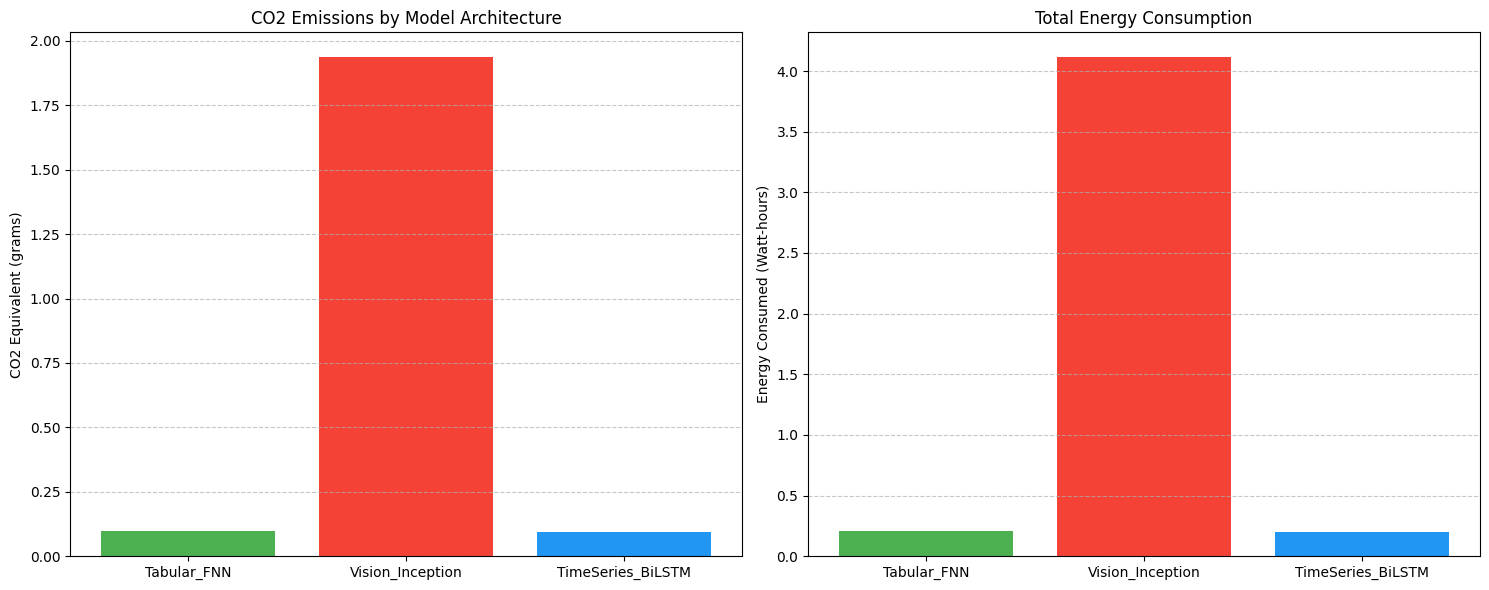


--- FINAL METRICS SUMMARY ---


,Architecture,Duration (seconds),Energy (kWh),CO2 Emitted (kg)
0,Tabular_FNN,21.721430,0.000209,0.000098
1,Vision_Inception,263.753169,0.004114,0.001937
2,TimeSeries_BiLSTM,15.208527,0.000196,0.000092


In [12]:
# CELL 5: VISUALIZE CARBON FOOTPRINT COMPARISON
print("\n--- RESULTS & CARBON FOOTPRINT ANALYSIS ---")

# Read the CSV generated by CodeCarbon
df_emissions = pd.read_csv('emissions.csv')

# Filter down to the latest run of our 3 projects
df_plot = df_emissions.drop_duplicates(subset=['project_name'], keep='last')

projects = df_plot['project_name'].values
co2_emissions = df_plot['emissions'].values * 1000  # Convert kg to grams for better readability
energy_consumed = df_plot['energy_consumed'].values * 1000 # Convert kWh to Wh

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: CO2 Emissions
bars1 = ax1.bar(projects, co2_emissions, color=['#4CAF50', '#F44336', '#2196F3'])
ax1.set_title('CO2 Emissions by Model Architecture')
ax1.set_ylabel('CO2 Equivalent (grams)')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Subplot 2: Energy Consumption
bars2 = ax2.bar(projects, energy_consumed, color=['#4CAF50', '#F44336', '#2196F3'])
ax2.set_title('Total Energy Consumption')
ax2.set_ylabel('Energy Consumed (Watt-hours)')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Print Final Summary Table
print("\n--- FINAL METRICS SUMMARY ---")
summary_df = df_plot[['project_name', 'duration', 'energy_consumed', 'emissions']].copy()
summary_df.columns = ['Architecture', 'Duration (seconds)', 'Energy (kWh)', 'CO2 Emitted (kg)']
display(summary_df)

In [15]:
#Setup and Model Architecture

In [16]:
# CELL 1: SETUP AND DATA PREPARATION
!pip install codecarbon -q

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from codecarbon import EmissionsTracker
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Load and normalize CIFAR-10
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0

# 2. Define a function to build a fresh CNN
def build_fresh_cnn():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

print("✅ Data loaded and CNN architecture defined. Ready for experiments.")

✅ Data loaded and CNN architecture defined. Ready for experiments.


In [17]:
#The Training Loop (10 vs 20 vs 30 Epochs)

In [18]:
# CELL 2: THE EPOCH EXPERIMENT
epochs_to_test = [10, 20, 30]
experiment_results = []

print("--- STARTING GREEN AI EPOCH EXPERIMENT ---")

for epochs in epochs_to_test:
    print(f"\n🚀 Training CNN for {epochs} Epochs...")

    # 1. Initialize fresh model
    model = build_fresh_cnn()

    # 2. Initialize CodeCarbon Tracker
    tracker = EmissionsTracker(project_name=f"CNN_{epochs}_Epochs", measure_power_secs=1)
    tracker.start()

    # 3. Train the model
    # We use a larger batch size (128) to keep Colab training fast
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=128, validation_split=0.1, verbose=1)

    # 4. Stop tracker and Evaluate
    emissions = tracker.stop()
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    print(f"✅ {epochs} Epochs Done | Accuracy: {test_acc:.4f} | CO2: {emissions:.6f} kg")

    # 5. Save results to our dictionary
    experiment_results.append({
        'Epochs': epochs,
        'Accuracy': test_acc * 100, # Convert to percentage
        'CO2_Emissions_g': emissions * 1000 # Convert kg to grams for plotting
    })

# Convert results to a DataFrame for easy viewing
df_results = pd.DataFrame(experiment_results)
display(df_results)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[codecarbon WARNING @ 15:42:59] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 15:42:59] [setup] RAM Tracking...
[codecarbon INFO @ 15:42:59] [setup] CPU Tracking...
[codecarbon WARNING @ 15:42:59] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 15:42:59] We will use the default power consumption of 4 W per thread for your 2 CPU, so 8W.
[codecarbon WARNING @ 15:42:59] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/in

--- STARTING GREEN AI EPOCH EXPERIMENT ---

🚀 Training CNN for 10 Epochs...


[codecarbon INFO @ 15:42:59] >>> Tracker's metadata:
[codecarbon INFO @ 15:42:59]   Platform system: Linux-6.6.122+-x86_64-with-glibc2.35
[codecarbon INFO @ 15:42:59]   Python version: 3.12.13
[codecarbon INFO @ 15:42:59]   CodeCarbon version: 3.2.8
[codecarbon INFO @ 15:42:59]   Available RAM : 12.671 GB
[codecarbon INFO @ 15:42:59]   CPU count: 2 thread(s) in 1 physical CPU(s)
[codecarbon INFO @ 15:42:59]   CPU model: Intel(R) Xeon(R) CPU @ 2.00GHz
[codecarbon INFO @ 15:42:59]   GPU count: 1
[codecarbon INFO @ 15:42:59]   GPU model: 1 x Tesla T4
[codecarbon WARNING @ 15:42:59] Unable to access geographical location through primary API. Will resort to using the backup API - Exception : Region is empty - url=https://get.geojs.io/v1/ip/geo.json
[codecarbon INFO @ 15:42:59] Emissions data (if any) will be saved to file /content/emissions.csv
[codecarbon INFO @ 15:43:01] Energy consumed for RAM : 0.000006 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 15:43:02] Delta energy consumed for CPU w

Epoch 1/10


[codecarbon INFO @ 15:43:06] Delta energy consumed for CPU with cpu_load : 0.000001 kWh, power : 8.0 W
[codecarbon INFO @ 15:43:06] Energy consumed for All CPU : 0.000012 kWh
[codecarbon INFO @ 15:43:06] Energy consumed for all GPUs : 0.000047 kWh. Total GPU Power : 33.13370094772477 W
[codecarbon INFO @ 15:43:06] 0.000073 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 15:43:06] Energy consumed for RAM : 0.000016 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 15:43:07] Delta energy consumed for CPU with cpu_load : 0.000001 kWh, power : 8.0 W
[codecarbon INFO @ 15:43:07] Energy consumed for All CPU : 0.000013 kWh
[codecarbon INFO @ 15:43:07] Energy consumed for all GPUs : 0.000056 kWh. Total GPU Power : 31.98297448862452 W
[codecarbon INFO @ 15:43:07] 0.000084 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 15:43:07] Energy consumed for RAM : 0.000017 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 15:43:0

...

[codecarbon INFO @ 15:45:49] Energy consumed for RAM : 0.000104 kWh. RAM Power : 10.0 W


352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8804 - loss: 0.3387 - val_accuracy: 0.7214 - val_loss: 1.0159


[codecarbon INFO @ 15:45:49] Energy consumed for RAM : 0.000105 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 15:45:49] Delta energy consumed for CPU with cpu_load : 0.000000 kWh, power : 2.9924469944 W
[codecarbon INFO @ 15:45:49] Energy consumed for All CPU : 0.000033 kWh
[codecarbon INFO @ 15:45:49] Energy consumed for all GPUs : 0.001249 kWh. Total GPU Power : 53.881558902079185 W
[codecarbon INFO @ 15:45:49] 0.001387 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 15:45:49] Delta energy consumed for CPU with cpu_load : 0.000000 kWh, power : 0.8098469432000002 W
[codecarbon INFO @ 15:45:49] Energy consumed for All CPU : 0.000033 kWh
[codecarbon INFO @ 15:45:49] Energy consumed for all GPUs : 0.001250 kWh. Total GPU Power : 69.85235462126408 W
[codecarbon INFO @ 15:45:49] 0.001388 kWh of electricity and 0.000000 L of water were used since the beginning.


✅ 30 Epochs Done | Accuracy: 0.7080 | CO2: 0.000654 kg


,Epochs,Accuracy,CO2_Emissions_g
0,10,67.739999,0.288301
1,20,70.410001,0.432053
2,30,70.800000,0.653588


In [19]:
#The Trade-Off Visualization

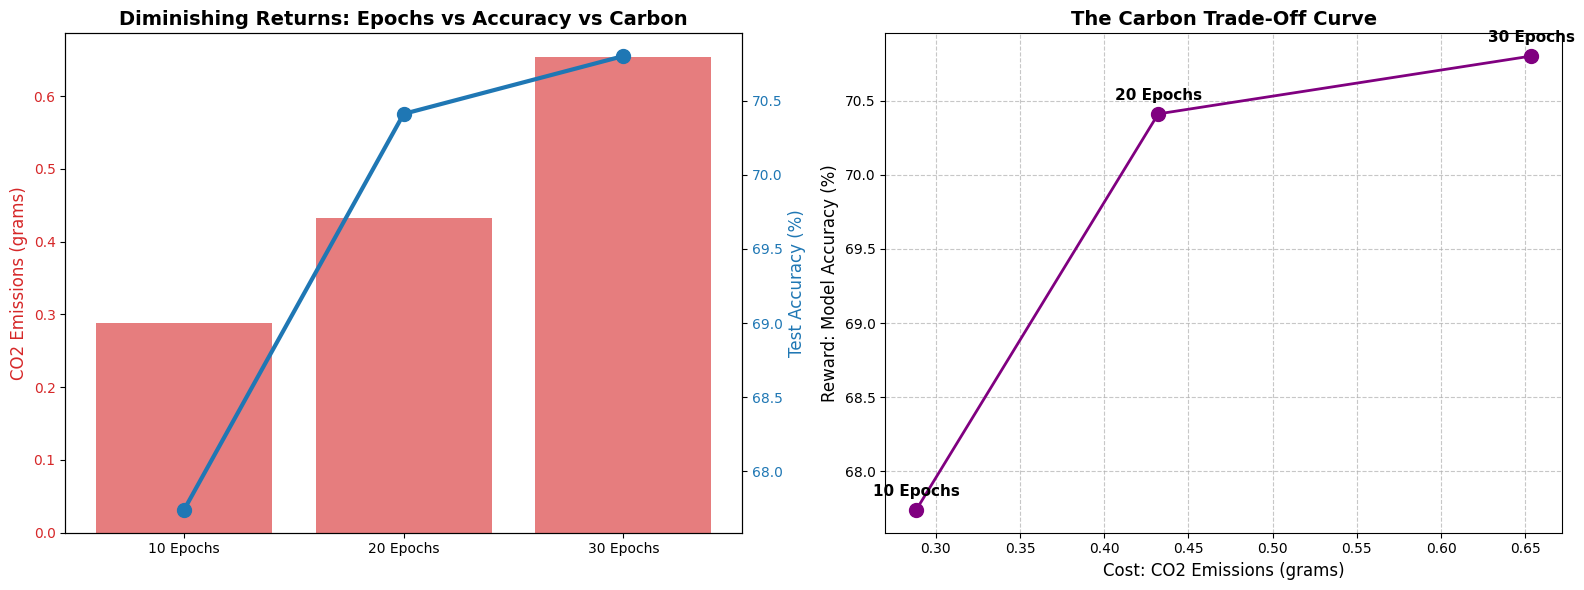

In [20]:
# CELL 3: VISUALIZING THE CARBON ROI (RETURN ON INVESTMENT)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- PLOT 1: Accuracy & Emissions vs. Epochs (Dual Axis) ---
color_acc = 'tab:blue'
color_co2 = 'tab:red'

# Bar chart for Emissions
ax1.bar(df_results['Epochs'].astype(str) + " Epochs", df_results['CO2_Emissions_g'], color=color_co2, alpha=0.6, label='CO2 Emitted (g)')
ax1.set_ylabel('CO2 Emissions (grams)', color=color_co2, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_co2)

# Line chart for Accuracy on the same plot
ax1_twin = ax1.twinx()
ax1_twin.plot(df_results['Epochs'].astype(str) + " Epochs", df_results['Accuracy'], color=color_acc, marker='o', linewidth=3, markersize=10, label='Accuracy (%)')
ax1_twin.set_ylabel('Test Accuracy (%)', color=color_acc, fontsize=12)
ax1_twin.tick_params(axis='y', labelcolor=color_acc)

ax1.set_title('Diminishing Returns: Epochs vs Accuracy vs Carbon', fontsize=14, fontweight='bold')

# --- PLOT 2: The Trade-Off Scatter Plot ---
ax2.plot(df_results['CO2_Emissions_g'], df_results['Accuracy'], marker='o', linestyle='-', color='purple', linewidth=2, markersize=10)

# Annotate the points so students know which dot is which epoch
for i, row in df_results.iterrows():
    ax2.annotate(f"{int(row['Epochs'])} Epochs",
                 (row['CO2_Emissions_g'], row['Accuracy']),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=11, fontweight='bold')

ax2.set_title('The Carbon Trade-Off Curve', fontsize=14, fontweight='bold')
ax2.set_xlabel('Cost: CO2 Emissions (grams)', fontsize=12)
ax2.set_ylabel('Reward: Model Accuracy (%)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [14]:
###your task now###

In [13]:
"""
================================================================================
🟢 STUDENT LAB TASK: MEASURE YOUR OWN AI CARBON FOOTPRINT 🟢
================================================================================

Now it's your turn! We have measured Tabular, Vision, and Time Series models.
Your task is to design a 4th experiment, measure its environmental impact,
and push your findings to our GitHub repository.

📝 INSTRUCTIONS:
1. CHOOSE A DATASET: Pick any dataset you like (e.g., from sklearn, keras.datasets,
   or load a custom CSV using pandas).
2. BUILD A MODEL: Design a new architecture (e.g., Random Forest, a deeper CNN,
   or even a Transformer if you want a challenge).
3. TRACK IT: Wrap your `.fit()` training process using CodeCarbon's `EmissionsTracker`.
4. EVALUATE: Print out the final Accuracy/Loss and the total CO2 Emitted.

🚀 HOW TO SUBMIT TO GITHUB:
Once your experiment is done, you need to save your work and push it to your
forked repository, specifically into a folder named `week-10-12-ai`.

Run the following commands in a new Colab cell when you are ready to submit:

# 1. Create the target directory
!mkdir -p week-10-12-ai

# 2. Move your newly generated emissions file into the folder
!cp emissions.csv week-10-12-ai/

# 3. Add, Commit, and Push via Git
!git add week-10-12-ai/
!git commit -m "feat: added custom Green AI experiment and carbon metrics"
!git push origin main

Finally, go to your GitHub account in your browser and open a Pull Request
to the Professor's main repository!
================================================================================
"""

# ==========================================
# WRITE YOUR EXPERIMENT CODE BELOW THIS LINE
# ==========================================
from codecarbon import EmissionsTracker
# Your code here...

In [10]:
!pip install tensorflow codecarbon yfinance -q

ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for tensorflow


In [9]:
# ================================================================================
# 🟢 CUSTOM GREEN AI EXPERIMENT: RANDOM FOREST ENSEMBLE ON DIGITS
# ================================================================================
print("\n--- STARTING CUSTOM EXPERIMENT 4: RANDOM FOREST ENSEMBLE ---")

import numpy as np
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from codecarbon import EmissionsTracker

# 1. Load and Preprocess Dataset (Handwritten Digits from sklearn)
digits = load_digits()
X_custom = digits.data
y_custom = digits.target

# Split into training and testing sets
X_train_custom, X_test_custom, y_train_custom, y_test_custom = train_test_split(
    X_custom, y_custom, test_size=0.2, random_state=42
)

# 2. Build a Random Forest Architecture (A brand-new model type not used in class!)
# We use 150 estimators (trees) to make the model powerful
model_custom = RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42)

# 3. Track Emissions using CodeCarbon
tracker_custom = EmissionsTracker(project_name="Custom_Random_Forest", measure_power_secs=1)
tracker_custom.start()

print("Training Custom Random Forest Classifier...")
# Train the ensemble model
model_custom.fit(X_train_custom, y_train_custom)

# 4. Stop Tracking and Evaluate Performance
emissions_custom = tracker_custom.stop()

# Predict and calculate accuracy
predictions = model_custom.predict(X_test_custom)
acc_custom = accuracy_score(y_test_custom, predictions)

print("\n--- CUSTOM EXPERIMENT RESULTS ---")
print(f"Custom Random Forest Test Accuracy: {acc_custom * 100:.2f}%")
print(f"CO2 Emitted for Custom Random Forest: {emissions_custom:.6f} kg")


--- STARTING CUSTOM EXPERIMENT 4: DEEP REGULARIZED CNN ---


ModuleNotFoundError: No module named 'tensorflow'